# Real-Time Fatigue Detection - Observed Model Evaluation
Evaluates the 1D-CNN fatigue detection model trained on organic phone data. It isolates the chronological last 20% of each recorded session as a hold-out test set to guarantee zero data leakage. Visualizes the Confusion Matrix, ROC Curve, and Precision-Recall Curve.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    mean_squared_error, roc_curve, auc, precision_recall_curve
)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [2]:
DATA_DIR = Path("observed-data")
MODEL_PATH = Path("model/fatigue_model_observed.keras")
TIMESTEPS = 128
STEP_SIZE = 64

def load_session(session_dir: Path) -> pd.DataFrame:
    acc_path = session_dir / "Accelerometer.csv"
    gyr_path = session_dir / "Gyroscope.csv"
    acc_df = pd.read_csv(acc_path)[["seconds_elapsed", "x", "y", "z"]].rename(columns={"x": "acc_x", "y": "acc_y", "z": "acc_z"})
    gyr_df = pd.read_csv(gyr_path)[["seconds_elapsed", "x", "y", "z"]].rename(columns={"x": "gyro_x", "y": "gyro_y", "z": "gyro_z"})
    acc_df = acc_df.sort_values("seconds_elapsed")
    gyr_df = gyr_df.sort_values("seconds_elapsed")
    merged = pd.merge_asof(acc_df, gyr_df, on="seconds_elapsed", direction="nearest", tolerance=0.05).dropna()
    return merged[["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]]

def extract_windows(df, window_size, step_size):
    arr = df.values
    windows = [arr[i : i + window_size] for i in range(0, len(arr) - window_size + 1, step_size)]
    return np.array(windows)

# Extract test set (last 20% of each session) and train stats for Z-score normalization
X_train_list, X_test_list, y_test_list = [], [], []

session_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
print("Loading hold-out test sets...")

for s_dir in session_dirs:
    if "class0" in s_dir.name.lower():
        label = 0
    elif "class1" in s_dir.name.lower():
        label = 1
    else: continue
        
    df = load_session(s_dir)
    n_rows = len(df)
    split_idx = int(n_rows * 0.8)
    
    # Train set just for normalization mean/std
    train_df = df.iloc[:split_idx]
    test_df  = df.iloc[split_idx:]
    
    X_tr = extract_windows(train_df, TIMESTEPS, STEP_SIZE)
    X_te = extract_windows(test_df, TIMESTEPS, STEP_SIZE)
    y_te = np.full(len(X_te), label)
    
    X_train_list.append(X_tr)
    X_test_list.append(X_te)
    y_test_list.append(y_te)
    print(f"  [{label}] {s_dir.name} -> {len(X_te)} test windows")

X_train_all = np.concatenate(X_train_list, axis=0)
X_test = np.concatenate(X_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)

# Normalize test set using training stats
train_mean = np.mean(X_train_all, axis=(0, 1), keepdims=True)
train_std = np.std(X_train_all, axis=(0, 1), keepdims=True) + 1e-8
X_test = (X_test - train_mean) / train_std

print(f"\nTotal Evaluation Samples: {len(X_test)}")

Loading hold-out test sets...
  [0] class0-optimal-2026-03-22_05-42-39 -> 65 test windows
  [0] class0-optimal1-2026-03-22_05-49-57 -> 74 test windows
  [1] class1-fatigue-2026-03-22_06-00-55 -> 67 test windows
  [1] class1-fatigue1-2026-03-22_06-10-48 -> 47 test windows

Total Evaluation Samples: 253


In [3]:
print("Loading model...")
model = tf.keras.models.load_model(MODEL_PATH)
print("Running predictions on validation set...")
y_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_true = y_test.astype(int)

Loading model...
Running predictions on validation set...


In [4]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
# RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_prob))

print("=== PERFORMANCE METRICS ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"RMSE     : {rmse:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=["Fresh (0)", "Fatigued (1)"]))

=== PERFORMANCE METRICS ===
Accuracy : 0.9368
Precision: 0.8952
Recall   : 0.9737
F1 Score : 0.9328
RMSE     : 0.2436

Classification Report:
               precision    recall  f1-score   support

   Fresh (0)       0.98      0.91      0.94       139
Fatigued (1)       0.90      0.97      0.93       114

    accuracy                           0.94       253
   macro avg       0.94      0.94      0.94       253
weighted avg       0.94      0.94      0.94       253



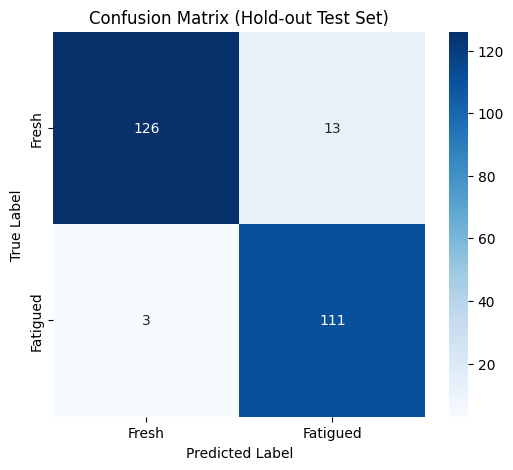

In [5]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Fresh", "Fatigued"], 
            yticklabels=["Fresh", "Fatigued"])
plt.title("Confusion Matrix (Hold-out Test Set)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

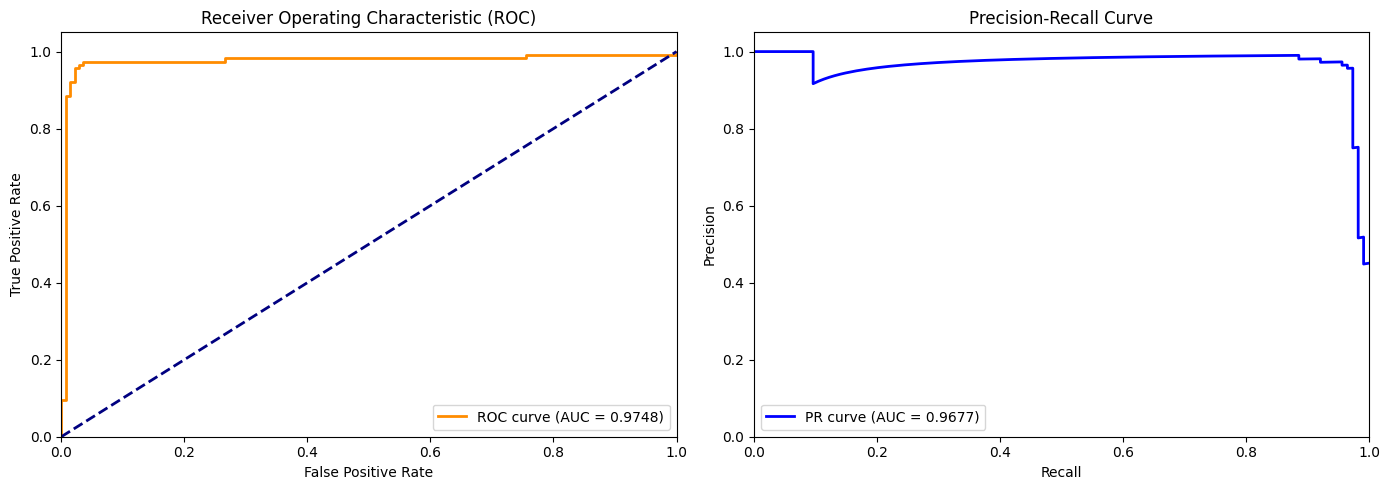

In [6]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
pr_auc = auc(recall_vals, precision_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend(loc="lower right")

# Precision-Recall Curve
ax2.plot(recall_vals, precision_vals, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()